# Quant Portfolio Reconstruction

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, coint
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')

## 1. Load data

| Ticker      | Type       | Description                                                         |
|--------------|------------|---------------------------------------------------------------------|
| VEGA         | Security   | A liquid equity security                                           |
| VEGA_C130    | Derivative | Derivative contract linked to VEGA. Strike 130, rolling annual expiry |
| VEGA_P110    | Derivative | Derivative contract linked to VEGA. Strike 110, rolling annual expiry |
| TERRA        | Security   | Equity security in a specific sector                               |
| SOLACE       | Security   | Equity security in a related sector                                |
| ANCHOR       | Security   | Fixed income security with coupon payments                         |
| NEON         | Security   | Alternative asset with non-standard return characteristics         |
| HELIX        | Index      | Sector index tracking industrial firms                             |
| CERES        | Commodity  | Physical commodity with seasonal demand patterns                   |
| PRISM        | Fund       | Pooled investment vehicle holding a basket of other instruments    |

In [2]:
df = pd.read_csv('datathon_train.csv', parse_dates=['Date'], index_col='Date')
prices = df.copy()
returns = prices.pct_change().dropna()
instruments = list(prices.columns)

print(f"Instruments: {instruments}")
print(f"Training period: {prices.index[0].date()} to {prices.index[-1].date()}")
print(f"Days: {len(prices)}")

Instruments: ['VEGA', 'VEGA_C130', 'VEGA_P110', 'TERRA', 'SOLACE', 'ANCHOR', 'NEON', 'HELIX', 'CERES', 'PRISM']
Training period: 2016-01-04 to 2023-09-01
Days: 2000


## 2. Price Chart

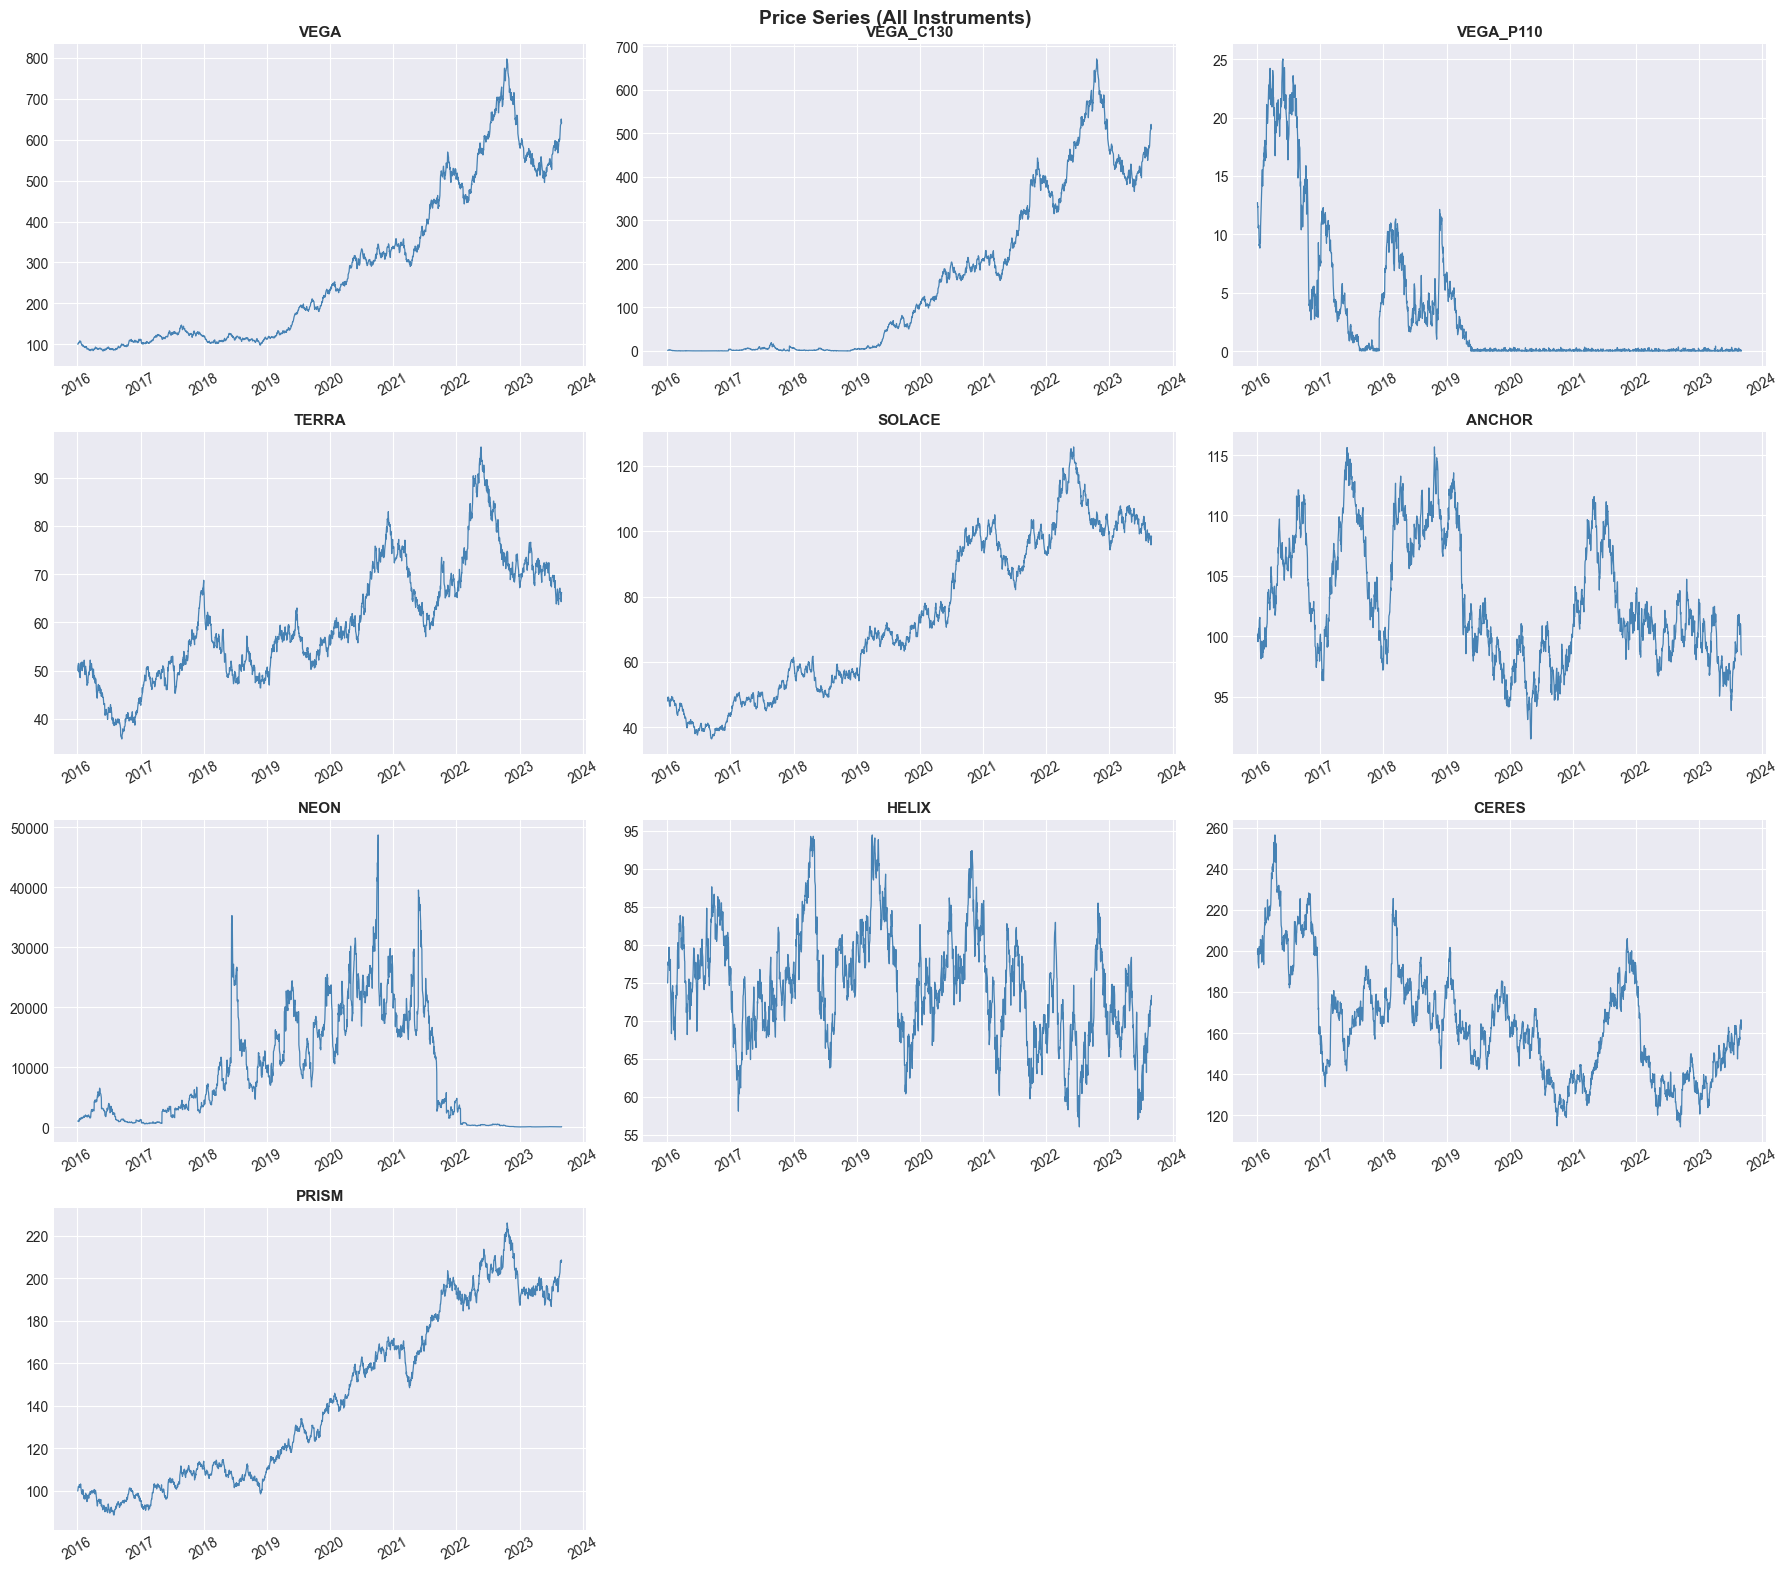

In [3]:
fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()
for i, inst in enumerate(instruments):
    axes[i].plot(prices.index, prices[inst], linewidth=0.9, color='steelblue')
    axes[i].set_title(inst, fontsize=11, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=30)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Price Series (All Instruments)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_01_prices.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Risk/return statistics


In [4]:
print("\nFULL UNIVERSE — RISK/RETURN SUMMARY")
print(f"{'Instrument':<12} {'Ann.Return':>12} {'Ann.Vol':>12} {'Sharpe':>10} {'MaxDD':>10}")
print("-" * 60)

stats = {}
for inst in instruments:
    r       = returns[inst]
    ann_ret = r.mean() * 252
    ann_vol = r.std() * np.sqrt(252)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else np.nan
    cum     = (1 + r).cumprod()
    max_dd  = ((cum - cum.cummax()) / cum.cummax()).min()
    stats[inst] = {'ann_ret': ann_ret, 'ann_vol': ann_vol,
                   'sharpe': sharpe,   'max_dd': max_dd}
    print(f"{inst:<12} {ann_ret:>11.2%} {ann_vol:>12.2%} {sharpe:>10.4f} {max_dd:>10.2%}")

stats_df = pd.DataFrame(stats).T


FULL UNIVERSE — RISK/RETURN SUMMARY
Instrument     Ann.Return      Ann.Vol     Sharpe      MaxDD
------------------------------------------------------------
VEGA              26.21%       23.62%     1.1096    -37.91%
VEGA_C130      13887.85%     6569.37%     2.1140    -99.95%
VEGA_P110      38484.52%     8807.86%     4.3693    -99.96%
TERRA              5.98%       22.10%     0.2705    -33.94%
SOLACE            10.72%       18.19%     0.5894    -26.32%
ANCHOR             0.35%       10.57%     0.0334    -20.91%
NEON             144.56%      216.64%     0.6673    -99.96%
HELIX              5.70%       34.63%     0.1647    -40.68%
CERES              1.59%       29.21%     0.0544    -55.44%
PRISM             10.03%       12.57%     0.7979    -17.37%


Notice that VEGA_C130 is a deep In The Money call, meaning it behaves similarly to the underlying asset. Having botH VEGA_C130 and VEGA will expose the portfolio twice. VEGA_P110 is a deep Out The Money put option, meaning it has 0 value. Unless VEGA drops to near the strike price, put option will stay at 0. Lastly, NEON is very volatile with low sharpe. Hence we will not proceed with these 3 assets.

## 4. Risk/return scatter

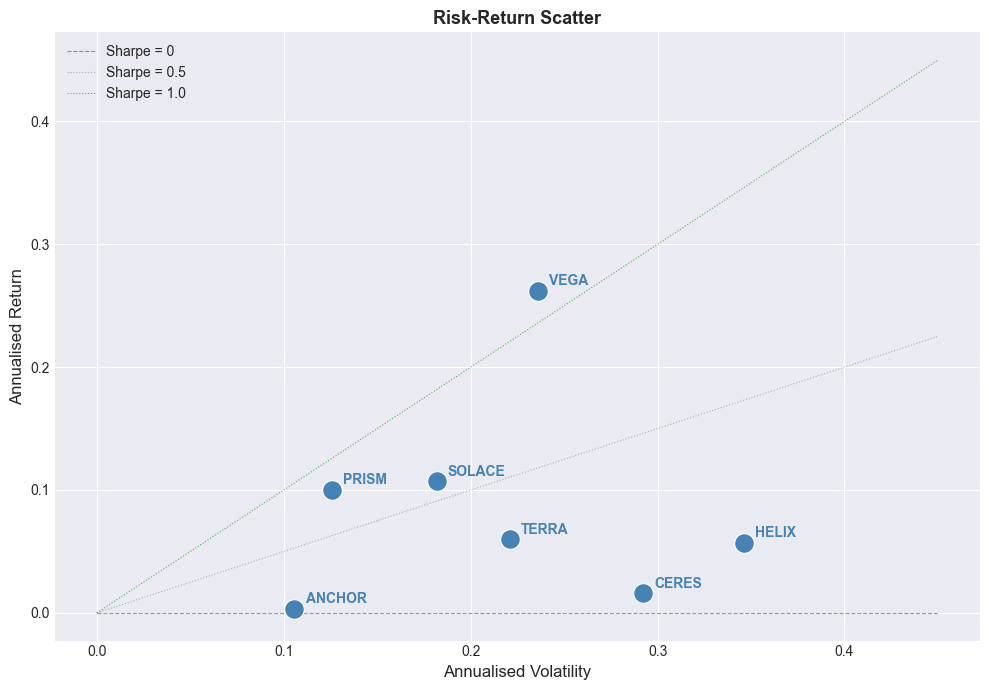

In [5]:
NORMAL      = ['VEGA', 'TERRA', 'SOLACE', 'HELIX', 'CERES', 'PRISM', 'ANCHOR']
fig, ax = plt.subplots(figsize=(10, 7))
for inst in NORMAL:
    v = stats[inst]
    ax.scatter(v['ann_vol'], v['ann_ret'], color='steelblue',
               s=200, zorder=5, edgecolors='white', linewidth=0.8)
    ax.annotate(inst, (v['ann_vol'], v['ann_ret']),
                textcoords='offset points', xytext=(8, 4),
                fontsize=10, fontweight='bold', color='steelblue')

vols = np.linspace(0, 0.45, 100)
ax.plot(vols, np.zeros_like(vols), 'k--',   linewidth=0.8, alpha=0.4, label='Sharpe = 0')
ax.plot(vols, 0.5 * vols,          'gray',  linewidth=0.8, linestyle=':', alpha=0.6, label='Sharpe = 0.5')
ax.plot(vols, 1.0 * vols,          'green', linewidth=0.8, linestyle=':', alpha=0.6, label='Sharpe = 1.0')
ax.set_xlabel('Annualised Volatility', fontsize=12)
ax.set_ylabel('Annualised Return', fontsize=12)
ax.set_title('Risk-Return Scatter', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('eda_03_risk_return_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Correlation heatmap

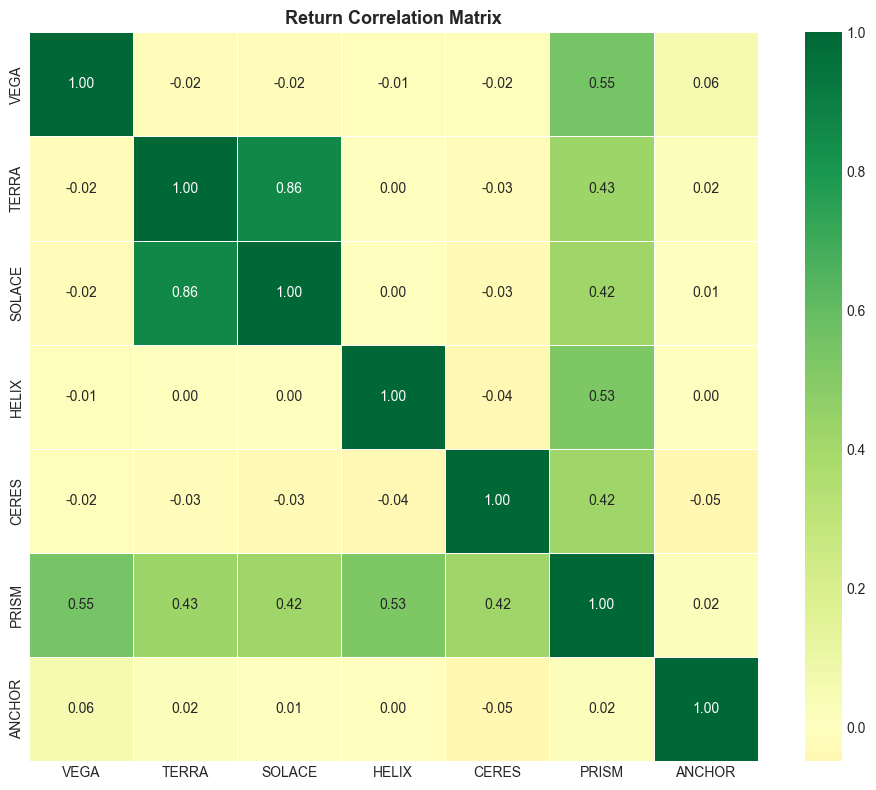


Correlation Matrix:
         VEGA  TERRA  SOLACE  HELIX  CERES  PRISM  ANCHOR
VEGA    1.000 -0.018  -0.016 -0.010 -0.015  0.546   0.062
TERRA  -0.018  1.000   0.860  0.002 -0.026  0.427   0.019
SOLACE -0.016  0.860   1.000  0.003 -0.031  0.420   0.008
HELIX  -0.010  0.002   0.003  1.000 -0.039  0.528   0.001
CERES  -0.015 -0.026  -0.031 -0.039  1.000  0.417  -0.048
PRISM   0.546  0.427   0.420  0.528  0.417  1.000   0.021
ANCHOR  0.062  0.019   0.008  0.001 -0.048  0.021   1.000


In [6]:
corr = returns[NORMAL].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            ax=ax, square=True, linewidths=0.5, annot_kws={'size': 10})
ax.set_title('Return Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_04_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCorrelation Matrix:")
print(corr.round(3))

## 6. ADF (Stationary) Test

In [7]:
print("\nADF Tests: Prices (expect NON-stationary)")
print(f"{'Instrument':<12} {'p-value':>10} {'Result':>20}")
print("-" * 45)
for inst in NORMAL:
    _, p, *_ = adfuller(prices[inst].dropna(), autolag='AIC')
    result = 'Stationary' if p < 0.05 else 'Non-stationary'
    print(f"{inst:<12} {p:>10.4f} {result:>20}")

print("\nADF Tests: Returns (expect stationary)")
print(f"{'Instrument':<12} {'p-value':>10} {'Result':>20}")
print("-" * 45)
for inst in NORMAL:
    _, p, *_ = adfuller(returns[inst].dropna(), autolag='AIC')
    result = 'Stationary' if p < 0.05 else 'Non-stationary'
    print(f"{inst:<12} {p:>10.4f} {result:>20}")


ADF Tests: Prices (expect NON-stationary)
Instrument      p-value               Result
---------------------------------------------
VEGA             0.9655       Non-stationary
TERRA            0.5013       Non-stationary
SOLACE           0.7895       Non-stationary
HELIX            0.0000           Stationary
CERES            0.0702       Non-stationary
PRISM            0.9515       Non-stationary
ANCHOR           0.0362           Stationary

ADF Tests: Returns (expect stationary)
Instrument      p-value               Result
---------------------------------------------
VEGA             0.0000           Stationary
TERRA            0.0000           Stationary
SOLACE           0.0000           Stationary
HELIX            0.0000           Stationary
CERES            0.0000           Stationary
PRISM            0.0000           Stationary
ANCHOR           0.0000           Stationary


## 7. Cointegration Test

In [8]:
print("Cointegration Tests (All Pairs)")
print(f"{'Pair':<25} {'p-value':>10} {'Cointegrated?':>15}")
print("-" * 55)

coint_pairs = []
for a, b in combinations(NORMAL, 2):
    try:
        _, p, _ = coint(prices[a], prices[b])
        result  = "YES" if p < 0.05 else "NO"
        if p < 0.05:
            coint_pairs.append((a, b, p))
        print(f"{a+' vs '+b:<25} {p:>10.4f} {result:>15}")
    except:
        print(f"{a+' vs '+b:<25} {'ERROR':>10}")

print(f"\nCointegrated pairs found: {len(coint_pairs)}")

Cointegration Tests (All Pairs)
Pair                         p-value   Cointegrated?
-------------------------------------------------------
VEGA vs TERRA                 0.6525              NO
VEGA vs SOLACE                0.5498              NO
VEGA vs HELIX                 0.5888              NO
VEGA vs CERES                 0.8225              NO
VEGA vs PRISM                 0.2387              NO
VEGA vs ANCHOR                0.7588              NO
TERRA vs SOLACE               0.2423              NO
TERRA vs HELIX                0.4446              NO
TERRA vs CERES                0.0608              NO
TERRA vs PRISM                0.2456              NO
TERRA vs ANCHOR               0.2544              NO
SOLACE vs HELIX               0.6049              NO
SOLACE vs CERES               0.2301              NO
SOLACE vs PRISM               0.0948              NO
SOLACE vs ANCHOR              0.4448              NO
HELIX vs CERES                0.0001             YES
HELIX vs PR

## 8. Pairs Trading Test


Pairs Trade Backtest (after transaction costs):
Pair                         Half-life   Num Trades    Sharpe (TC)
-----------------------------------------------------------------
HELIX vs CERES                   26.5d            5         0.7634
HELIX vs PRISM                   24.4d            7         1.0618
HELIX vs ANCHOR                  26.9d            3         0.4629
CERES vs PRISM                   59.8d            3         0.4120


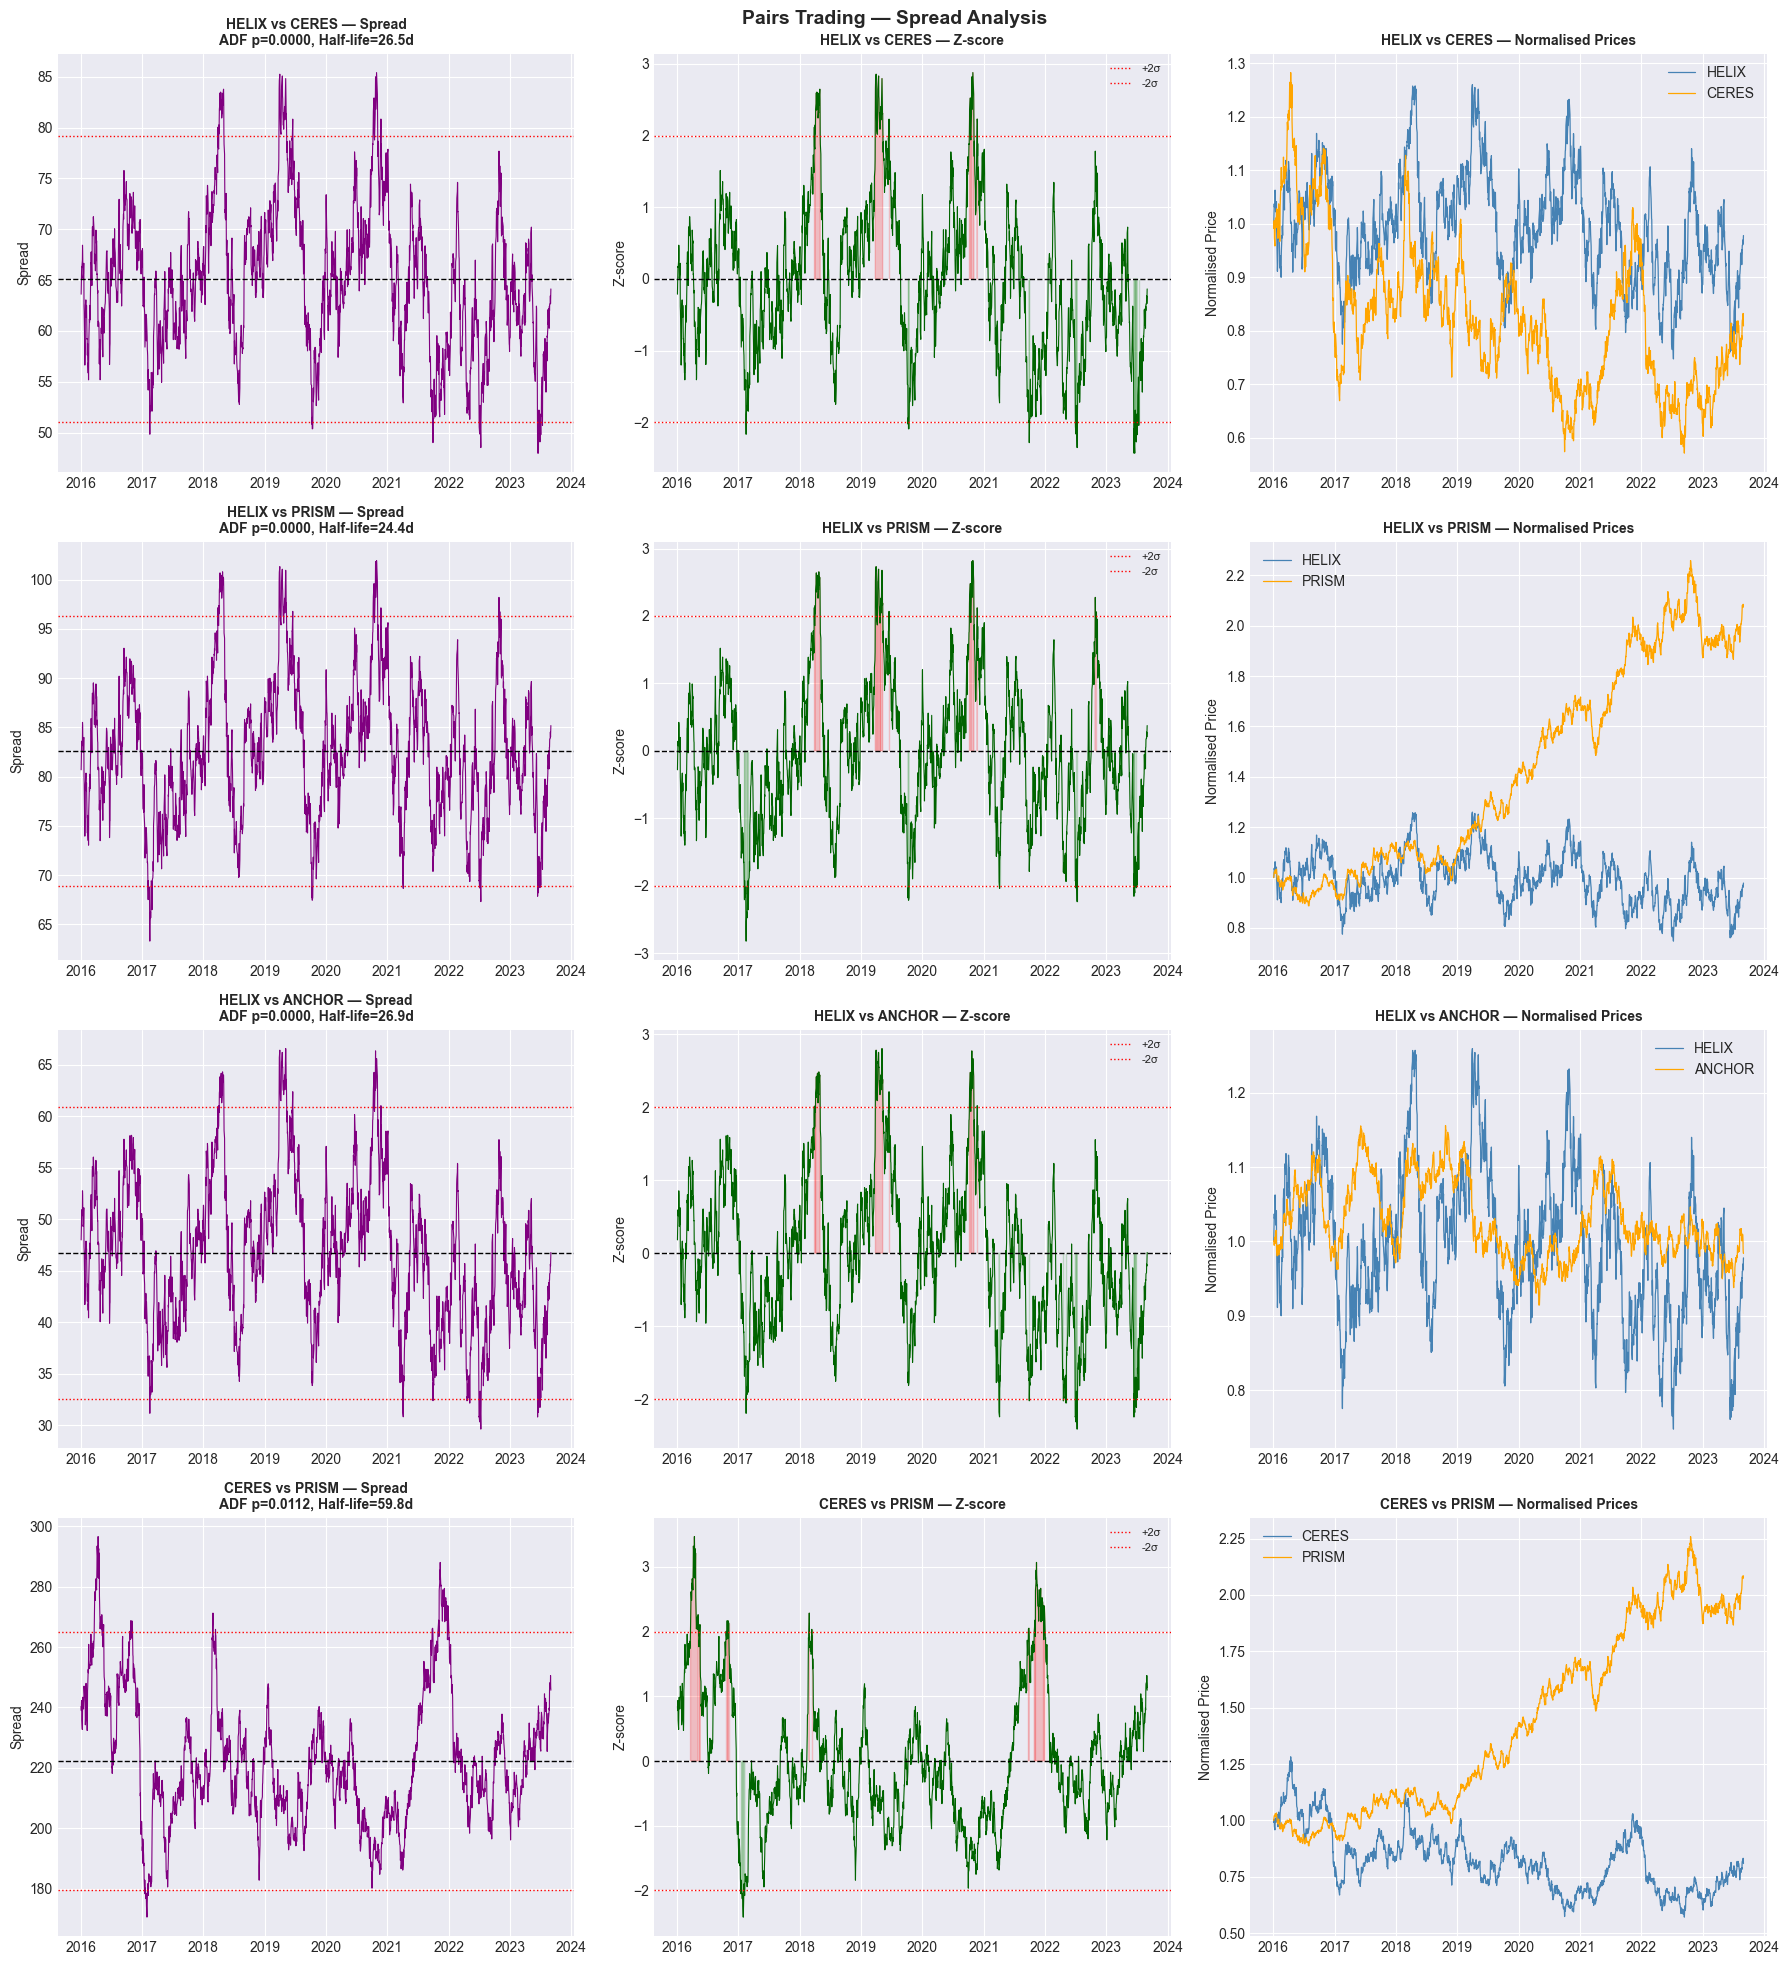

In [9]:

if coint_pairs:
    TC = 0.0005

    print("\nPairs Trade Backtest (after transaction costs):")
    print(f"{'Pair':<25} {'Half-life':>12} {'Num Trades':>12} {'Sharpe (TC)':>14}")
    print("-" * 65)

    for a, b, p_coint in coint_pairs:
        hedge_ratio = np.polyfit(prices[b], prices[a], 1)[0]
        spread      = prices[a] - hedge_ratio * prices[b]
        spread_mean = spread.mean()
        spread_std  = spread.std()

        spread_lag  = spread.shift(1).dropna()
        spread_diff = spread.diff().dropna()
        beta        = np.polyfit(spread_lag, spread_diff, 1)[0]
        half_life   = -np.log(2) / beta if beta < 0 else np.inf
        hl_str      = f"{half_life:.1f}d" if half_life != np.inf else "∞"

        zscore = (spread - spread_mean) / spread_std
        signal = pd.Series(0.0, index=zscore.index)
        signal[zscore >  2] = -1
        signal[zscore < -2] =  1
        signal[zscore.abs() < 0.5] = 0
        signal = signal.replace(0, np.nan).ffill().fillna(0)

        spread_ret  = spread.pct_change()
        pair_ret    = signal.shift(1) * spread_ret
        pair_ret   -= signal.diff().abs() * TC

        pair_sharpe = (pair_ret.mean()*252) / (pair_ret.std()*np.sqrt(252))
        n_trades    = int((signal.diff().abs() > 0).sum())

        print(f"{a+' vs '+b:<25} {hl_str:>12} {n_trades:>12} {pair_sharpe:>14.4f}")

    fig, axes = plt.subplots(len(coint_pairs), 3,
                             figsize=(18, 5 * len(coint_pairs)))
    if len(coint_pairs) == 1:
        axes = axes.reshape(1, -1)

    for i, (a, b, p_coint) in enumerate(coint_pairs):
        hedge_ratio = np.polyfit(prices[b], prices[a], 1)[0]
        spread      = prices[a] - hedge_ratio * prices[b]
        spread_mean = spread.mean()
        spread_std  = spread.std()
        zscore      = (spread - spread_mean) / spread_std
        _, p_spread, *_ = adfuller(spread.dropna(), autolag='AIC')
        spread_lag  = spread.shift(1).dropna()
        spread_diff = spread.diff().dropna()
        beta        = np.polyfit(spread_lag, spread_diff, 1)[0]
        half_life   = -np.log(2) / beta if beta < 0 else np.inf
        hl_str      = f"{half_life:.1f}d" if half_life != np.inf else "∞"

        axes[i, 0].plot(spread.index, spread.values, color='purple', linewidth=0.8)
        axes[i, 0].axhline(spread_mean,                color='black', linestyle='--', linewidth=1)
        axes[i, 0].axhline(spread_mean + 2*spread_std, color='red',   linestyle=':', linewidth=1)
        axes[i, 0].axhline(spread_mean - 2*spread_std, color='red',   linestyle=':', linewidth=1)
        axes[i, 0].set_title(f'{a} vs {b} — Spread\nADF p={p_spread:.4f}, Half-life={hl_str}',
                             fontsize=10, fontweight='bold')
        axes[i, 0].set_ylabel('Spread')

        axes[i, 1].plot(zscore.index, zscore.values, color='darkgreen', linewidth=0.8)
        axes[i, 1].axhline(0,  color='black', linestyle='--', linewidth=1)
        axes[i, 1].axhline(2,  color='red',   linestyle=':', linewidth=1, label='+2σ')
        axes[i, 1].axhline(-2, color='red',   linestyle=':', linewidth=1, label='-2σ')
        axes[i, 1].fill_between(zscore.index, zscore.values, 0,
                                 where=zscore >  2, color='red',   alpha=0.2)
        axes[i, 1].fill_between(zscore.index, zscore.values, 0,
                                 where=zscore < -2, color='green', alpha=0.2)
        axes[i, 1].set_title(f'{a} vs {b} — Z-score', fontsize=10, fontweight='bold')
        axes[i, 1].set_ylabel('Z-score')
        axes[i, 1].legend(fontsize=8)

        norm_a = prices[a] / prices[a].iloc[0]
        norm_b = prices[b] / prices[b].iloc[0]
        axes[i, 2].plot(norm_a.index, norm_a.values, label=a, linewidth=0.9, color='steelblue')
        axes[i, 2].plot(norm_b.index, norm_b.values, label=b, linewidth=0.9, color='orange')
        axes[i, 2].set_title(f'{a} vs {b} — Normalised Prices', fontsize=10, fontweight='bold')
        axes[i, 2].set_ylabel('Normalised Price')
        axes[i, 2].legend()

    plt.suptitle('Pairs Trading — Spread Analysis', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('eda_05_pairs_spread.png', dpi=150, bbox_inches='tight')
    plt.show()


## 9. Portfolio Combination Testing

In [10]:

print("\nExhaustive Combination Testing")
print(f"{'Combination':<58} {'Sharpe':>8} {'Size':>6}")
print("-" * 75)

combo_results = []
for r in range(1, len(NORMAL)+1):
    for combo in combinations(NORMAL, r):
        ret = returns[list(combo)].mean(axis=1)
        s   = (ret.mean()*252) / (ret.std()*np.sqrt(252))
        combo_results.append((list(combo), s))

combo_results.sort(key=lambda x: -x[1])

print("Top 15 combinations (any size):")
for combo, s in combo_results[:15]:
    print(f"  {str(combo):<55} {s:>8.4f}  ({len(combo)})")

combo_min3 = [(c, s) for c, s in combo_results if len(c) >= 3]
best_combo, best_sharpe = combo_min3[0]

print(f"\nTop 10 combinations with at least 3 instruments:")
print(f"{'Combination':<58} {'Sharpe':>8} {'Size':>6}")
print("-" * 75)
for combo, s in combo_min3[:10]:
    print(f"  {str(combo):<55} {s:>8.4f}  ({len(combo)})")


Exhaustive Combination Testing
Combination                                                  Sharpe   Size
---------------------------------------------------------------------------
Top 15 combinations (any size):
  ['VEGA', 'SOLACE']                                        1.2484  (2)
  ['VEGA', 'SOLACE', 'PRISM']                               1.1932  (3)
  ['VEGA', 'SOLACE', 'ANCHOR']                              1.1669  (3)
  ['VEGA', 'SOLACE', 'PRISM', 'ANCHOR']                     1.1474  (4)
  ['VEGA', 'PRISM']                                         1.1237  (2)
  ['VEGA']                                                  1.1096  (1)
  ['VEGA', 'PRISM', 'ANCHOR']                               1.0617  (3)
  ['VEGA', 'TERRA', 'PRISM']                                1.0102  (3)
  ['VEGA', 'TERRA']                                         1.0042  (2)
  ['VEGA', 'ANCHOR']                                        1.0037  (2)
  ['VEGA', 'TERRA', 'PRISM', 'ANCHOR']                      0.975

## 10. Portfolio Weighting, Fitting, and Backtesting

Candidates (Equal Weight + Optimised for each top 10 combo):
Name                                          Weights
--------------------------------------------------------------------------------
EW  | VEGA+SOLACE+PRISM                       VEGA:0.33  SOLACE:0.33  PRISM:0.33
OPT | VEGA+SOLACE+PRISM                       VEGA:0.51  SOLACE:0.39  PRISM:0.10
EW  | VEGA+SOLACE+ANCHOR                      VEGA:0.33  SOLACE:0.33  ANCHOR:0.33
OPT | VEGA+SOLACE+ANCHOR                      VEGA:0.50  SOLACE:0.40  ANCHOR:0.10
EW  | VEGA+SOLACE+PRISM+ANCHOR                VEGA:0.25  SOLACE:0.25  PRISM:0.25  ANCHOR:0.25
OPT | VEGA+SOLACE+PRISM+ANCHOR                VEGA:0.45  SOLACE:0.35  PRISM:0.10  ANCHOR:0.10
EW  | VEGA+PRISM+ANCHOR                       VEGA:0.33  PRISM:0.33  ANCHOR:0.33
OPT | VEGA+PRISM+ANCHOR                       VEGA:0.56  PRISM:0.34  ANCHOR:0.10
EW  | VEGA+TERRA+PRISM                        VEGA:0.33  TERRA:0.33  PRISM:0.33
OPT | VEGA+TERRA+PRISM                        VE

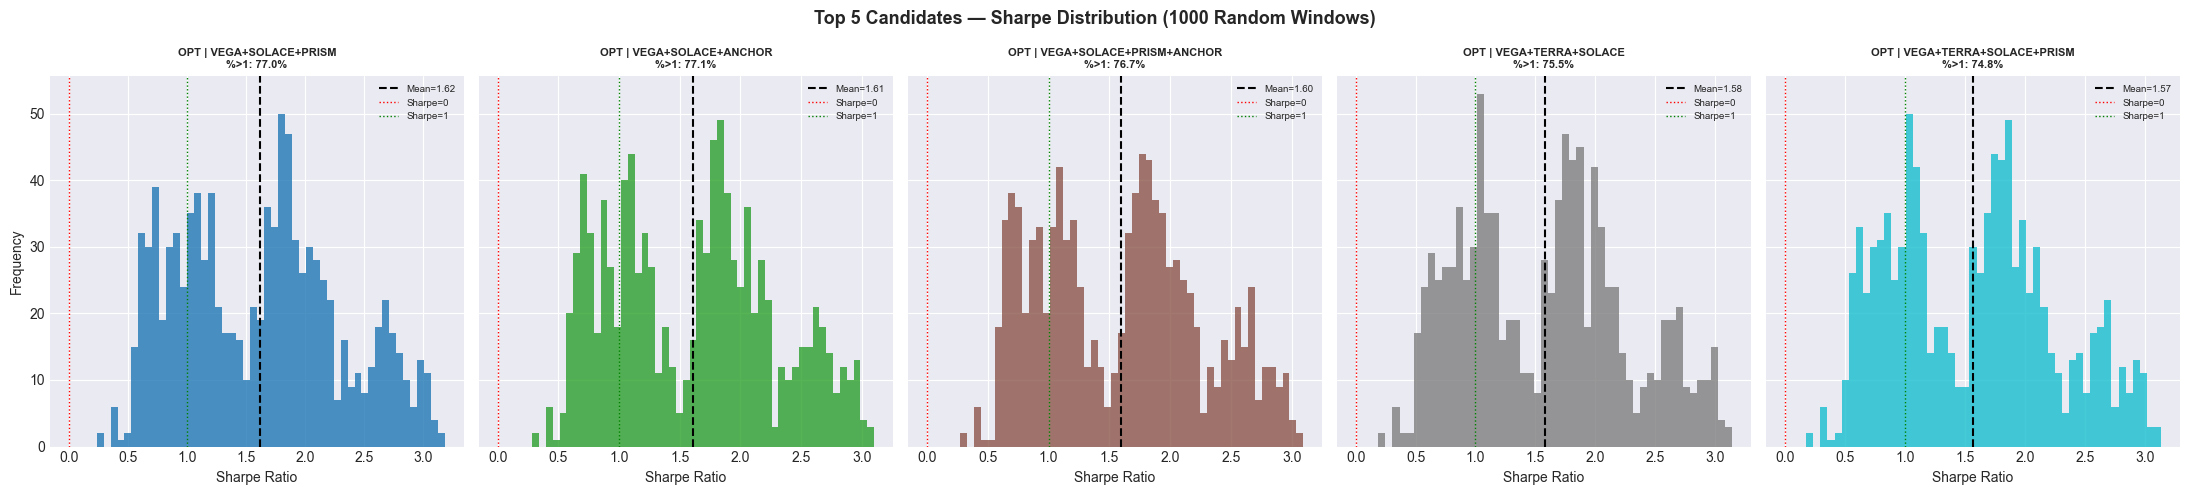

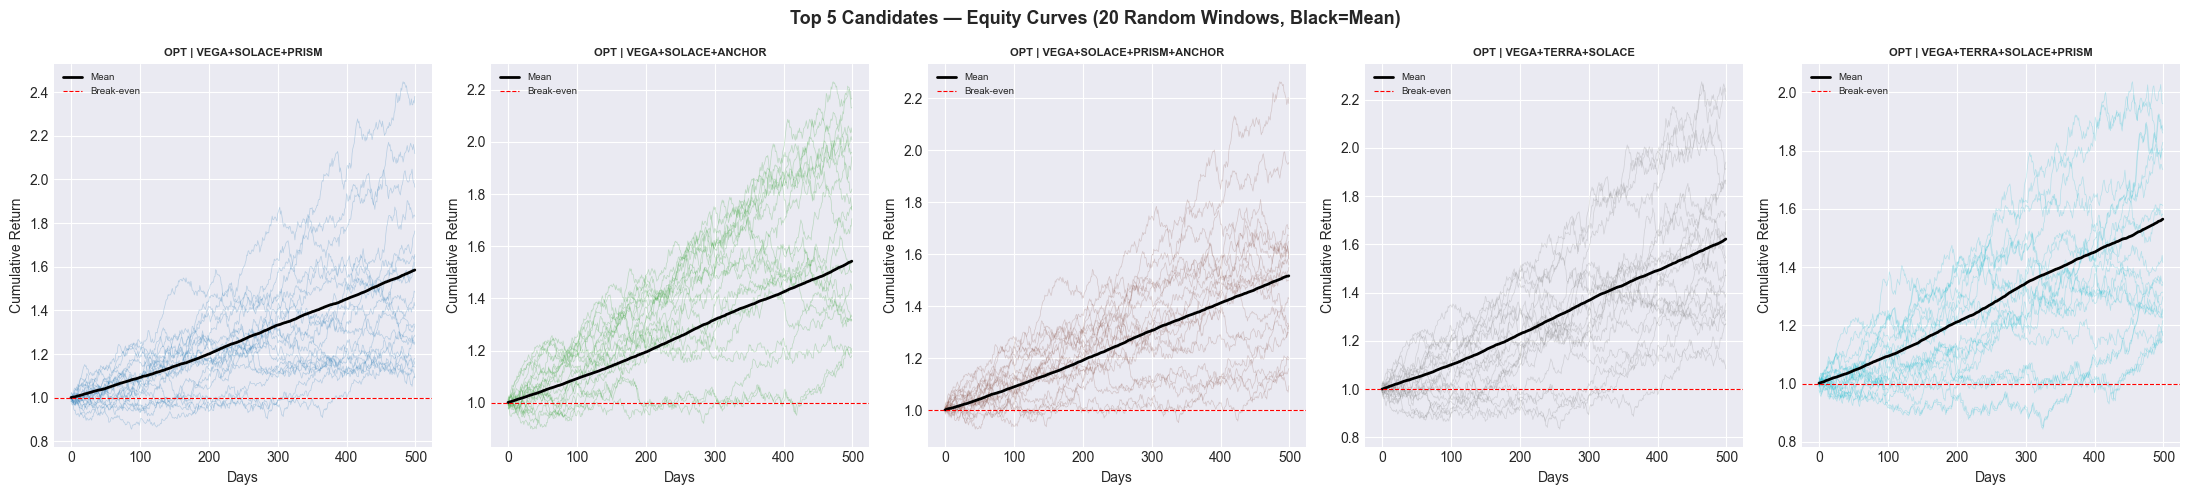


Top 3 Candidates:
Rank   Candidate                                         Mean     %>0     %>1
---------------------------------------------------------------------------
1      OPT | VEGA+SOLACE+PRISM                         1.6173  100.0%   77.0%
       Weights: {'VEGA': 0.5073, 'SOLACE': 0.3927, 'PRISM': 0.1}

2      OPT | VEGA+SOLACE+ANCHOR                        1.6099  100.0%   77.1%
       Weights: {'VEGA': 0.5013, 'SOLACE': 0.3987, 'ANCHOR': 0.1}

3      OPT | VEGA+SOLACE+PRISM+ANCHOR                  1.5961  100.0%   76.7%
       Weights: {'VEGA': 0.4514, 'SOLACE': 0.3486, 'PRISM': 0.1, 'ANCHOR': 0.1}



In [11]:
# 1. Setup
# Requires combo_min3 from Section 12 (Combination Testing)
# Requires returns, np, pd, plt already loaded

from scipy.optimize import minimize

TC          = 0.0005
N_SIMS      = 1000
WINDOW_SIZE = 500

def max_sharpe_weights(ret_data, bounds=(0.10, 0.70)):
    mean_ret = ret_data.mean() * 252
    cov      = ret_data.cov() * 252
    n        = len(ret_data.columns)
    def neg_sharpe(w):
        w = np.array(w)
        return -(w @ mean_ret) / np.sqrt(w @ cov.values @ w)
    result = minimize(
        neg_sharpe,
        x0=[1/n]*n,
        method='SLSQP',
        bounds=[bounds]*n,
        constraints={'type': 'eq', 'fun': lambda w: np.sum(w)-1}
    )
    return pd.Series(result.x, index=ret_data.columns)


# 2. Build Candidates From Top 10 Combinations

candidates = {}
for combo, is_sharpe in combo_min3[:10]:
    assets = list(combo)
    name   = '+'.join(assets)
    ew     = pd.Series(1/len(assets), index=assets)
    opt    = max_sharpe_weights(returns[assets].iloc[:1500])
    candidates[f'EW  | {name}']  = (assets, ew)
    candidates[f'OPT | {name}'] = (assets, opt)

print("Candidates (Equal Weight + Optimised for each top 10 combo):")
print(f"{'Name':<45} {'Weights'}")
print("-" * 80)
for name, (assets, w) in candidates.items():
    w_str = '  '.join([f"{a}:{v:.2f}" for a, v in w.items()])
    print(f"{name:<45} {w_str}")


# 3. Random Holdout Simulation

np.random.seed(None)
sim_sharpes = {name: [] for name in candidates}

for _ in range(N_SIMS):
    start = np.random.randint(0, len(returns) - WINDOW_SIZE)
    end   = start + WINDOW_SIZE

    for name, (assets, w) in candidates.items():
        period   = returns[assets].iloc[start:end]
        port_ret = (period * w).sum(axis=1)
        port_ret.iloc[0] -= TC * w.abs().sum()
        s = (port_ret.mean()*252) / (port_ret.std()*np.sqrt(252))
        sim_sharpes[name].append(s)


# 4. Results Table

print(f"\nRandom Holdout Simulation ({N_SIMS} windows of {WINDOW_SIZE} days)")
print(f"{'Candidate':<45} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8} {'%>0':>7} {'%>1':>7}")
print("-" * 95)

results = []
for name in candidates:
    arr = np.array(sim_sharpes[name])
    results.append({
        'name':    name,
        'mean':    arr.mean(),
        'std':     arr.std(),
        'min':     arr.min(),
        'max':     arr.max(),
        'pct_0':   (arr > 0).mean() * 100,
        'pct_1':   (arr > 1).mean() * 100,
    })

results.sort(key=lambda x: -x['mean'])
for r in results:
    print(f"{r['name']:<45} {r['mean']:>8.4f} {r['std']:>8.4f} "
          f"{r['min']:>8.4f} {r['max']:>8.4f} "
          f"{r['pct_0']:>6.1f}% {r['pct_1']:>6.1f}%")


# 5. Top 5 Candidates Distribution Plot

top5 = [r['name'] for r in results[:5]]
colors = plt.cm.tab10(np.linspace(0, 1, 5))

fig, axes = plt.subplots(1, 5, figsize=(22, 5), sharey=True)
for idx, (name, color) in enumerate(zip(top5, colors)):
    arr = np.array(sim_sharpes[name])
    axes[idx].hist(arr, bins=50, color=color, edgecolor='none', alpha=0.8)
    axes[idx].axvline(arr.mean(), color='black', linewidth=1.5, linestyle='--',
                      label=f'Mean={arr.mean():.2f}')
    axes[idx].axvline(0, color='red',   linewidth=1.0, linestyle=':', label='Sharpe=0')
    axes[idx].axvline(1, color='green', linewidth=1.0, linestyle=':', label='Sharpe=1')
    axes[idx].set_title(f'{name}\n%>1: {(arr>1).mean()*100:.1f}%',
                        fontsize=8, fontweight='bold')
    axes[idx].set_xlabel('Sharpe Ratio')
    axes[idx].legend(fontsize=7)

axes[0].set_ylabel('Frequency')
plt.suptitle(f'Top 5 Candidates — Sharpe Distribution ({N_SIMS} Random Windows)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('robustness_top5_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


# 6. Equity Curves — Top 5 Candidates

N_CURVES = 20
fig, axes = plt.subplots(1, 5, figsize=(22, 5))

for idx, (name, color) in enumerate(zip(top5, colors)):
    assets, w = candidates[name]
    np.random.seed(None)

    # Sample curves
    for _ in range(N_CURVES):
        start    = np.random.randint(0, len(returns) - WINDOW_SIZE)
        period   = returns[assets].iloc[start:start+WINDOW_SIZE]
        port_ret = (period * w).sum(axis=1)
        cum      = (1 + port_ret).cumprod().reset_index(drop=True)
        axes[idx].plot(cum, color=color, linewidth=0.5, alpha=0.25)

    # Mean curve
    mean_cum = []
    for _ in range(N_SIMS):
        start    = np.random.randint(0, len(returns) - WINDOW_SIZE)
        period   = returns[assets].iloc[start:start+WINDOW_SIZE]
        port_ret = (period * w).sum(axis=1)
        mean_cum.append((1 + port_ret).cumprod().reset_index(drop=True).values)

    axes[idx].plot(np.mean(mean_cum, axis=0), color='black', linewidth=2.0, label='Mean')
    axes[idx].axhline(1.0, color='red', linewidth=0.8, linestyle='--', label='Break-even')
    axes[idx].set_title(name, fontsize=8, fontweight='bold')
    axes[idx].set_xlabel('Days')
    axes[idx].set_ylabel('Cumulative Return')
    axes[idx].legend(fontsize=7)

plt.suptitle(f'Top 5 Candidates — Equity Curves ({N_CURVES} Random Windows, Black=Mean)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('robustness_top5_equity.png', dpi=150, bbox_inches='tight')
plt.show()


# 7. Decision


print("\nTop 3 Candidates:")
print(f"{'Rank':<6} {'Candidate':<45} {'Mean':>8} {'%>0':>7} {'%>1':>7}")
print("-" * 75)
for rank, r in enumerate(results[:3], 1):
    print(f"{rank:<6} {r['name']:<45} {r['mean']:>8.4f} {r['pct_0']:>6.1f}% {r['pct_1']:>6.1f}%")
    print(f"{'':6} Weights: {candidates[r['name']][1].round(4).to_dict()}")
    print()

## 11. Risk Management

Portfolios from top 3 robustness candidates:
Name                                          Weights
--------------------------------------------------------------------------------
OPT | VEGA+SOLACE+PRISM                       VEGA:0.51  SOLACE:0.39  PRISM:0.10
OPT | VEGA+SOLACE+ANCHOR                      VEGA:0.50  SOLACE:0.40  ANCHOR:0.10
OPT | VEGA+SOLACE+PRISM+ANCHOR                VEGA:0.45  SOLACE:0.35  PRISM:0.10  ANCHOR:0.10
  RISK MANAGEMENT METRICS COMPARISON
Metric                      OPT | VEGA+SOLACE+PRISMOPT | VEGA+SOLACE+ANCHOROPT | VEGA+SOLACE+PRISM+ANCHOR
-------------------------------------------------------------------------------------
Annualised Return                     18.5030%          17.4431%          16.6013%
Annualised Volatility                 14.7460%          13.8880%          13.3165%
Sharpe Ratio                            1.2548            1.2560            1.2467
Calmar Ratio                            0.8091            0.7997            0.7807
Ma

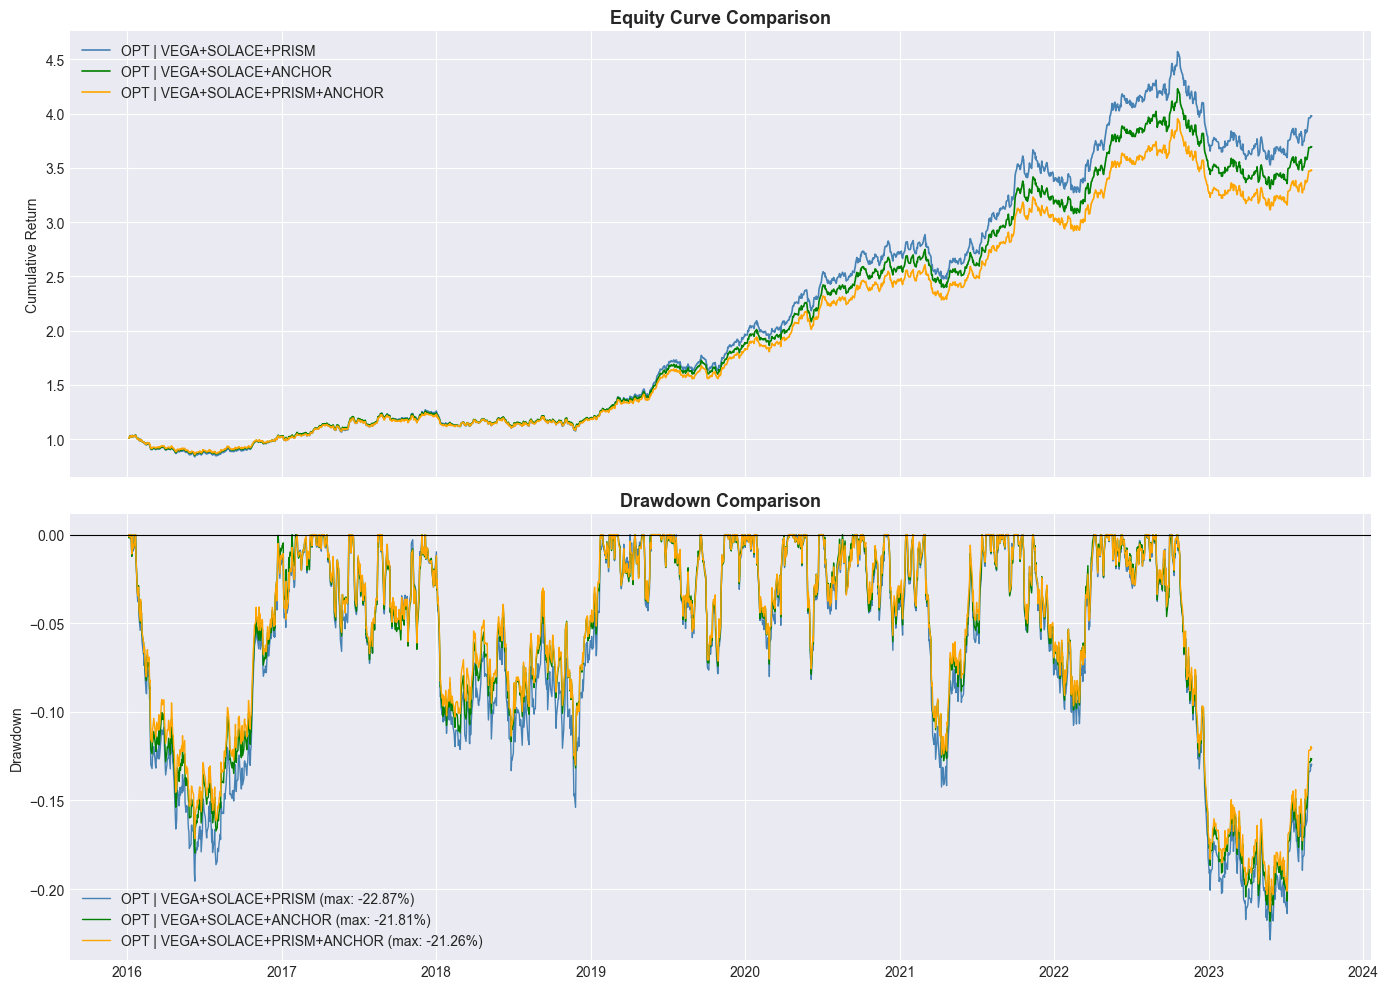

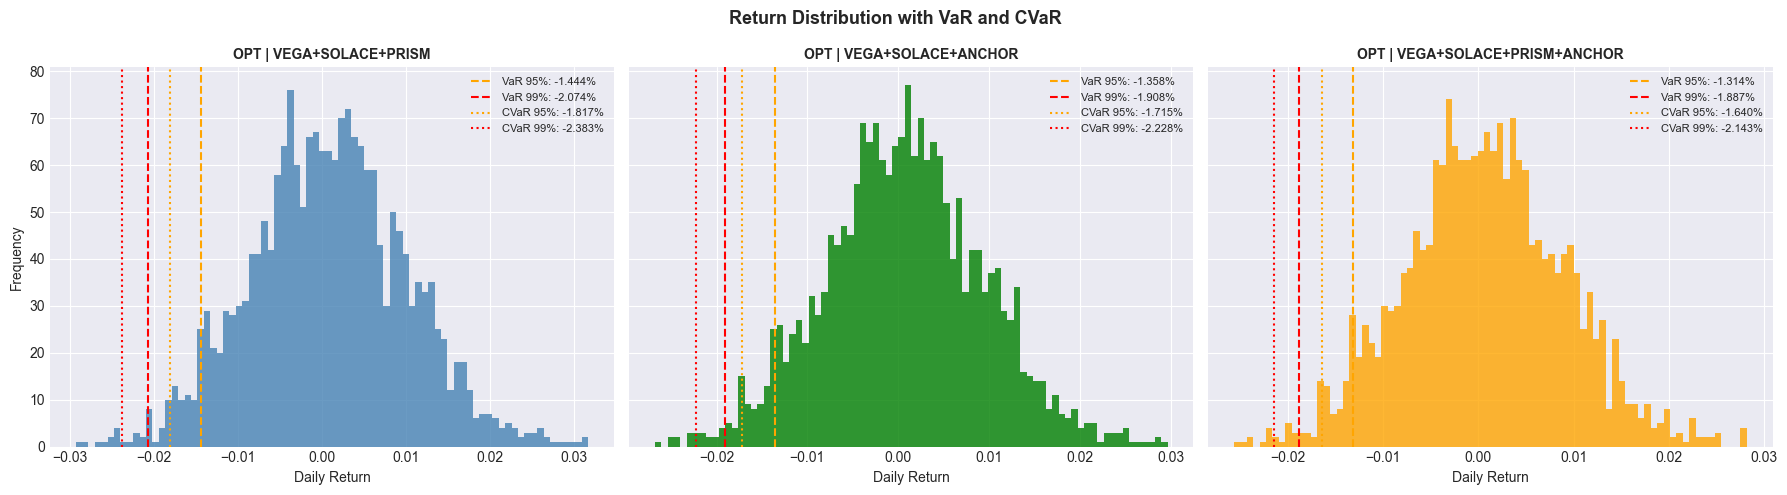

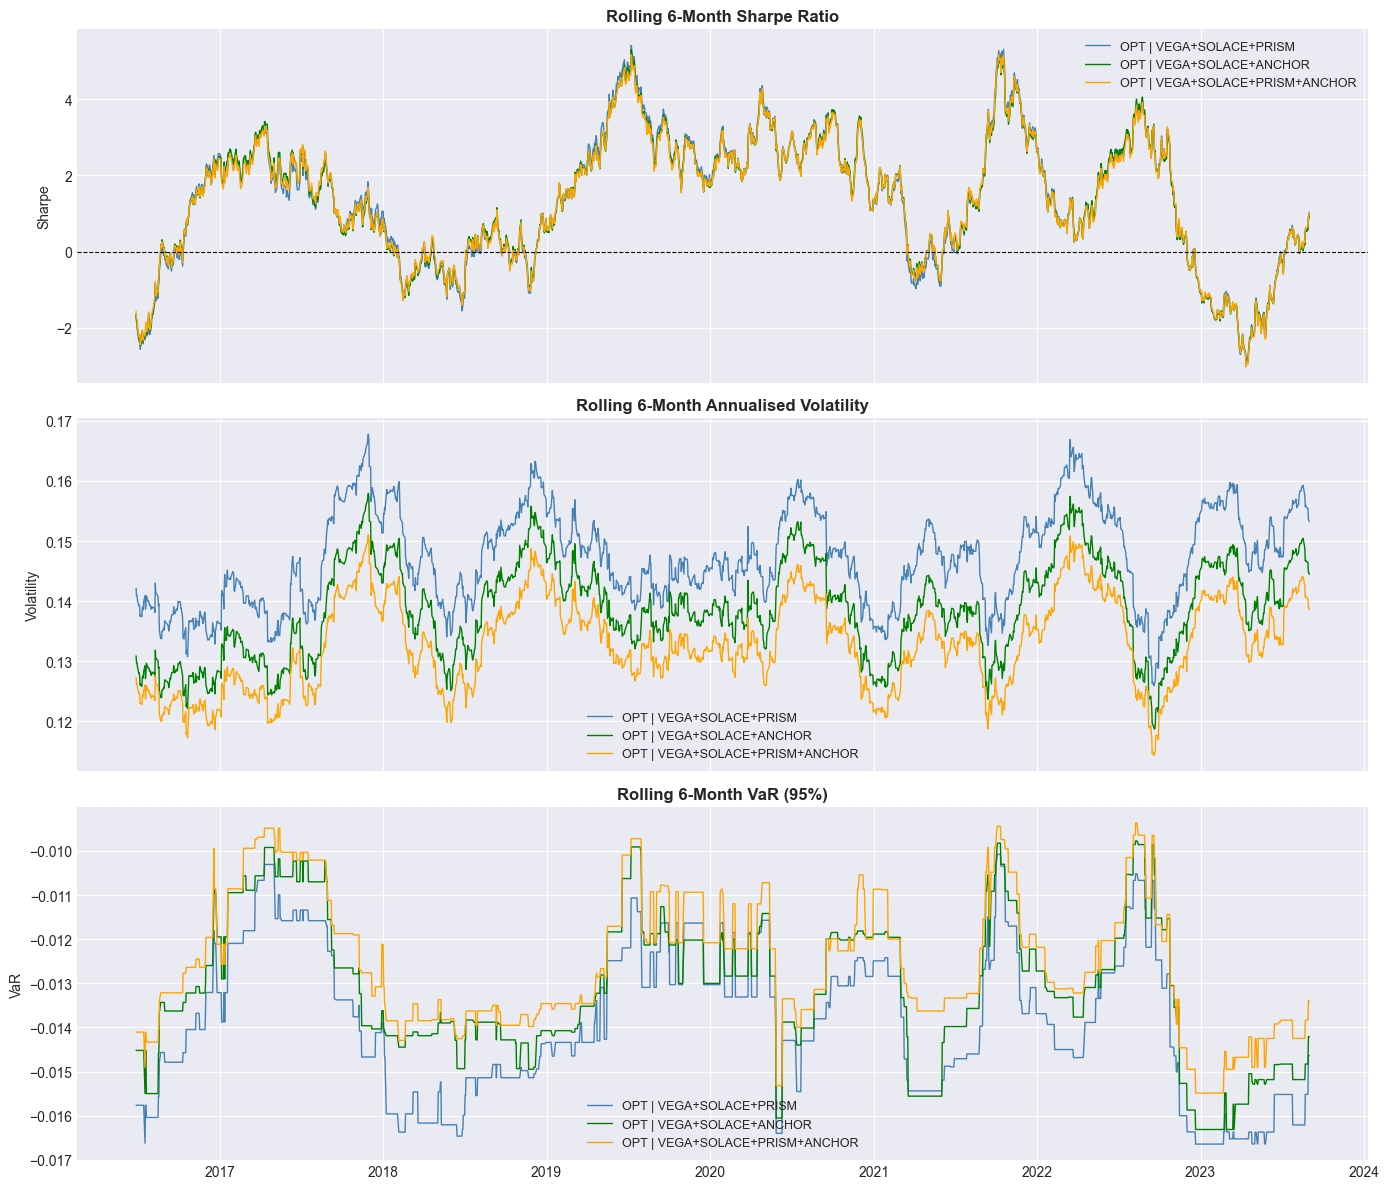


Stress Test Comparison
Scenario              OPT | VEGA+SOLACE+PRISMOPT | VEGA+SOLACE+ANCHOROPT | VEGA+SOLACE+PRISM+ANCHOR
----------------------------------------------------------------------------------------
-10% equity shock                   -9.8000%              -8.8000%              -8.6000%
-20% equity shock                  -19.5000%             -17.7000%             -17.2000%
-30% equity crash                  -29.0000%             -26.5000%             -25.5000%
-50% severe crash                  -48.5000%             -44.2000%             -42.7000%
VEGA only -30%                     -15.2185%             -15.0391%             -13.5433%
SOLACE only -30%                   -11.7815%             -11.9609%             -10.4567%
+20% rally                          19.5000%              18.1000%              17.6000%

Top 5 Drawdown Periods per Portfolio:

OPT | VEGA+SOLACE+PRISM:
     Start        End  Duration  Drawdown
2016-01-22 2017-02-06       381 -0.195527
2017-12-07 2019

In [12]:
# 1. Setup

top3 = results[:3]
portfolios = {r['name']: candidates[r['name']][1] for r in top3}

print("Portfolios from top 3 robustness candidates:")
print(f"{'Name':<45} {'Weights'}")
print("-" * 80)
for name, w in portfolios.items():
    w_str = '  '.join([f"{a}:{v:.2f}" for a, v in w.items()])
    print(f"{name:<45} {w_str}")

TC = 0.0005

# Compute returns and cumulative returns for each portfolio
port_rets = {}
cum_rets  = {}
drawdowns = {}

for name, w in portfolios.items():
    assets   = list(w.index)
    r        = (returns[assets] * w).sum(axis=1).copy()
    r.iloc[0] -= TC * w.abs().sum()
    cum      = (1 + r).cumprod()
    dd       = (cum - cum.cummax()) / cum.cummax()
    port_rets[name] = r
    cum_rets[name]  = cum
    drawdowns[name] = dd


# 2. Performance Metrics Comparison

print("=" * 85)
print("  RISK MANAGEMENT METRICS COMPARISON")
print("=" * 85)
print(f"{'Metric':<28}", end="")
for name in portfolios:
    print(f"{name:>18}", end="")
print()
print("-" * 85)

metrics = {}
for name, r in port_rets.items():
    ann_ret = r.mean() * 252
    ann_vol = r.std() * np.sqrt(252)
    sharpe  = ann_ret / ann_vol
    max_dd  = drawdowns[name].min()
    calmar  = ann_ret / abs(max_dd)
    var_95  = np.percentile(r, 5)
    var_99  = np.percentile(r, 1)
    cvar_95 = r[r <= var_95].mean()
    cvar_99 = r[r <= var_99].mean()
    metrics[name] = {
        'ann_ret': ann_ret, 'ann_vol': ann_vol, 'sharpe': sharpe,
        'max_dd': max_dd,   'calmar': calmar,
        'var_95': var_95,   'var_99': var_99,
        'cvar_95': cvar_95, 'cvar_99': cvar_99,
        'skew': r.skew(),   'kurt': r.kurt(),
        'win_rate': (r > 0).mean()
    }

rows = [
    ('Annualised Return',     'ann_ret',  '{:.4%}'),
    ('Annualised Volatility', 'ann_vol',  '{:.4%}'),
    ('Sharpe Ratio',          'sharpe',   '{:.4f}'),
    ('Calmar Ratio',          'calmar',   '{:.4f}'),
    ('Max Drawdown',          'max_dd',   '{:.4%}'),
    ('VaR  (95%, 1-day)',     'var_95',   '{:.4%}'),
    ('VaR  (99%, 1-day)',     'var_99',   '{:.4%}'),
    ('CVaR (95%, 1-day)',     'cvar_95',  '{:.4%}'),
    ('CVaR (99%, 1-day)',     'cvar_99',  '{:.4%}'),
    ('Skewness',              'skew',     '{:.4f}'),
    ('Excess Kurtosis',       'kurt',     '{:.4f}'),
    ('Win Rate',              'win_rate', '{:.4%}'),
]

for label, key, fmt in rows:
    print(f"{label:<28}", end="")
    for name in portfolios:
        val = metrics[name][key]
        print(f"{fmt.format(val):>18}", end="")
    print()

print("=" * 85)


# 3. Equity Curve + Drawdown Comparison

color_list = ['steelblue', 'green', 'orange']
colors = {name: color_list[i] for i, name in enumerate(portfolios)}

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

for name in portfolios:
    axes[0].plot(cum_rets[name].index, cum_rets[name].values,
                 color=colors[name], linewidth=1.2, label=name)
axes[0].set_title('Equity Curve Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Cumulative Return')
axes[0].legend()

for name in portfolios:
    axes[1].plot(drawdowns[name].index, drawdowns[name].values,
                 color=colors[name], linewidth=1.0, label=f"{name} (max: {metrics[name]['max_dd']:.2%})")
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Drawdown Comparison', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Drawdown')
axes[1].legend()

plt.tight_layout()
plt.savefig('risk_01_equity_drawdown.png', dpi=150, bbox_inches='tight')
plt.show()


# 4. VaR / CVaR Histogram Comparison

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for idx, (name, r) in enumerate(port_rets.items()):
    var_95  = metrics[name]['var_95']
    var_99  = metrics[name]['var_99']
    cvar_95 = metrics[name]['cvar_95']
    cvar_99 = metrics[name]['cvar_99']
    axes[idx].hist(r, bins=80, color=colors[name], edgecolor='none', alpha=0.8)
    axes[idx].axvline(var_95,  color='orange', linewidth=1.5, linestyle='--', label=f'VaR 95%: {var_95:.3%}')
    axes[idx].axvline(var_99,  color='red',    linewidth=1.5, linestyle='--', label=f'VaR 99%: {var_99:.3%}')
    axes[idx].axvline(cvar_95, color='orange', linewidth=1.5, linestyle=':',  label=f'CVaR 95%: {cvar_95:.3%}')
    axes[idx].axvline(cvar_99, color='red',    linewidth=1.5, linestyle=':',  label=f'CVaR 99%: {cvar_99:.3%}')
    axes[idx].set_title(name, fontsize=10, fontweight='bold')
    axes[idx].set_xlabel('Daily Return')
    axes[idx].legend(fontsize=8)

axes[0].set_ylabel('Frequency')
plt.suptitle('Return Distribution with VaR and CVaR', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('risk_02_var_cvar.png', dpi=150, bbox_inches='tight')
plt.show()


# 5. Rolling Risk Metrics Comparison

ROLL = 126

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

for name, r in port_rets.items():
    roll_sharpe = r.rolling(ROLL).apply(
        lambda x: (x.mean()*252)/(x.std()*np.sqrt(252)) if x.std() > 0 else 0)
    roll_vol = r.rolling(ROLL).std() * np.sqrt(252)
    roll_var = r.rolling(ROLL).quantile(0.05)

    axes[0].plot(roll_sharpe.index, roll_sharpe.values,
                 color=colors[name], linewidth=1.0, label=name)
    axes[1].plot(roll_vol.index, roll_vol.values,
                 color=colors[name], linewidth=1.0, label=name)
    axes[2].plot(roll_var.index, roll_var.values,
                 color=colors[name], linewidth=1.0, label=name)

axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Rolling 6-Month Sharpe Ratio', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Sharpe')
axes[0].legend(fontsize=9)

axes[1].set_title('Rolling 6-Month Annualised Volatility', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Volatility')
axes[1].legend(fontsize=9)

axes[2].set_title('Rolling 6-Month VaR (95%)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('VaR')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('risk_03_rolling_metrics.png', dpi=150, bbox_inches='tight')
plt.show()


# 6. Stress Test Comparison

scenarios = {
    '-10% equity shock':  {'VEGA': -0.10, 'SOLACE': -0.10, 'PRISM': -0.08, 'ANCHOR':  0.02},
    '-20% equity shock':  {'VEGA': -0.20, 'SOLACE': -0.20, 'PRISM': -0.15, 'ANCHOR':  0.03},
    '-30% equity crash':  {'VEGA': -0.30, 'SOLACE': -0.30, 'PRISM': -0.20, 'ANCHOR':  0.05},
    '-50% severe crash':  {'VEGA': -0.50, 'SOLACE': -0.50, 'PRISM': -0.35, 'ANCHOR':  0.08},
    'VEGA only -30%':     {'VEGA': -0.30, 'SOLACE':  0.00, 'PRISM':  0.00, 'ANCHOR':  0.00},
    'SOLACE only -30%':   {'VEGA':  0.00, 'SOLACE': -0.30, 'PRISM':  0.00, 'ANCHOR':  0.00},
    '+20% rally':         {'VEGA':  0.20, 'SOLACE':  0.20, 'PRISM':  0.15, 'ANCHOR':  0.01},
}

print("\nStress Test Comparison")
print(f"{'Scenario':<22}", end="")
for name in portfolios:
    print(f"{name:>22}", end="")
print()
print("-" * (22 + 22 * len(portfolios)))

for scenario, shocks in scenarios.items():
    print(f"{scenario:<22}", end="")
    for name, w in portfolios.items():
        shock = pd.Series({k: shocks.get(k, 0) for k in w.index})
        port_shock = (w * shock).sum()
        print(f"{port_shock:>22.4%}", end="")
    print()


# 7. Drawdown Period Analysis

print("\nTop 5 Drawdown Periods per Portfolio:")

for name, cum in cum_rets.items():
    dd_periods = []
    in_dd      = False
    start_dd   = None
    peak_val   = cum.iloc[0]
    trough_val = cum.iloc[0]

    for date, val in cum.items():
        if val >= peak_val:
            if in_dd:
                dd_periods.append({
                    'Start':    start_dd,
                    'End':      date,
                    'Duration': (date - start_dd).days,
                    'Drawdown': (trough_val / peak_val) - 1
                })
                in_dd = False
            peak_val = val
        else:
            if not in_dd:
                in_dd      = True
                start_dd   = date
                trough_val = val
            if val < trough_val:
                trough_val = val

    dd_df = pd.DataFrame(dd_periods).sort_values('Drawdown').head(5)
    print(f"\n{name}:")
    print(dd_df.to_string(index=False))


# 8. Decision

print("\nDECISION SUMMARY")
print(f"{'Metric':<28}", end="")
for name in portfolios:
    print(f"{name:>22}", end="")
print()
print("-" * (28 + 22 * len(portfolios)))

decision_metrics = [
    ('Sharpe',    'sharpe',   '{:.4f}'),
    ('Max DD',    'max_dd',   '{:.4%}'),
    ('CVaR 95%',  'cvar_95',  '{:.4%}'),
    ('Ann. Vol',  'ann_vol',  '{:.4%}'),
]

for label, key, fmt in decision_metrics:
    print(f"{label:<28}", end="")
    vals = [metrics[n][key] for n in portfolios]
    for name, val in zip(portfolios, vals):
        print(f"{fmt.format(val):>22}", end="")
    print()

## 12. Generate team_weights.csv
Strategy: buy and hold — same weights every day for 500 days

In [13]:
N_TEST     = 500
TC         = 0.0005
ALL_ASSETS = ['VEGA', 'VEGA_C130', 'VEGA_P110', 'TERRA', 'SOLACE',
              'ANCHOR', 'NEON', 'HELIX', 'CERES', 'PRISM']  # exact order from brief

# Final weights — pulled from best candidate in risk management
# Automatically uses top 3 decision — change index to pick 2nd or 3rd best
final_name, final_weights = list(portfolios.items())[2]
print(f"Selected portfolio: {final_name}")
print(f"Weights: {final_weights.round(4).to_dict()}")

# Build 500-day weight schedule — same weights every day
rows = []
for day in range(1, N_TEST + 1):
    row = {'Day': day}
    for asset in ALL_ASSETS:
        row[asset] = round(final_weights.get(asset, 0.0), 6)
    rows.append(row)

weights_df = pd.DataFrame(rows, columns=['Day'] + ALL_ASSETS)

# Confirm column order matches brief exactly
expected_cols = ['Day', 'VEGA', 'VEGA_C130', 'VEGA_P110', 'TERRA', 'SOLACE',
                 'ANCHOR', 'NEON', 'HELIX', 'CERES', 'PRISM']
assert list(weights_df.columns) == expected_cols, "Column order mismatch!"

# Validation
print(f"\nValidation:")
print(f"  Rows:           {len(weights_df)} (expected 500)")
print(f"  Columns:        {list(weights_df.columns)}")
print(f"  Null values:    {weights_df.isnull().sum().sum()}")
print(f"  Day range:      {weights_df['Day'].min()} to {weights_df['Day'].max()}")
print(f"  Total exposure: {weights_df.drop(columns='Day').sum(axis=1).mean():.4f}")

# Save
weights_df.to_csv('team_weights.csv', index=False, float_format='%.6f')
print(f"\nteam_weights.csv saved!")

Selected portfolio: OPT | VEGA+SOLACE+PRISM+ANCHOR
Weights: {'VEGA': 0.4514, 'SOLACE': 0.3486, 'PRISM': 0.1, 'ANCHOR': 0.1}

Validation:
  Rows:           500 (expected 500)
  Columns:        ['Day', 'VEGA', 'VEGA_C130', 'VEGA_P110', 'TERRA', 'SOLACE', 'ANCHOR', 'NEON', 'HELIX', 'CERES', 'PRISM']
  Null values:    0
  Day range:      1 to 500
  Total exposure: 1.0000

team_weights.csv saved!


## 13. Final portfolio backtest

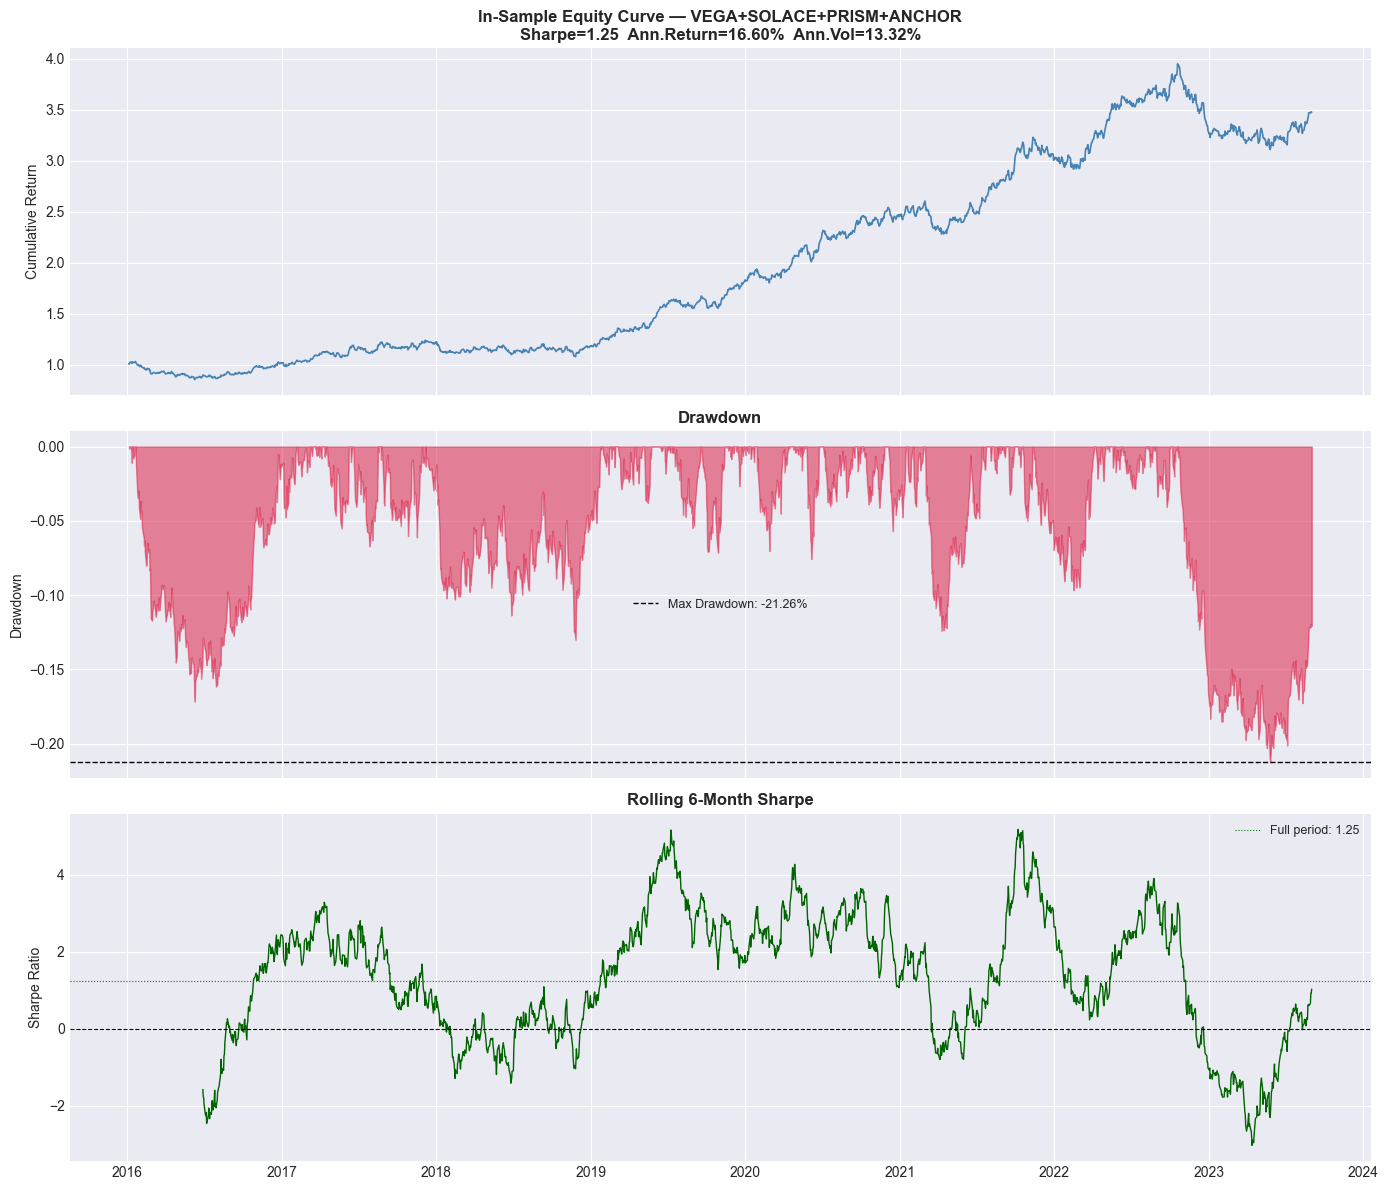

✅ equity_curve.png saved


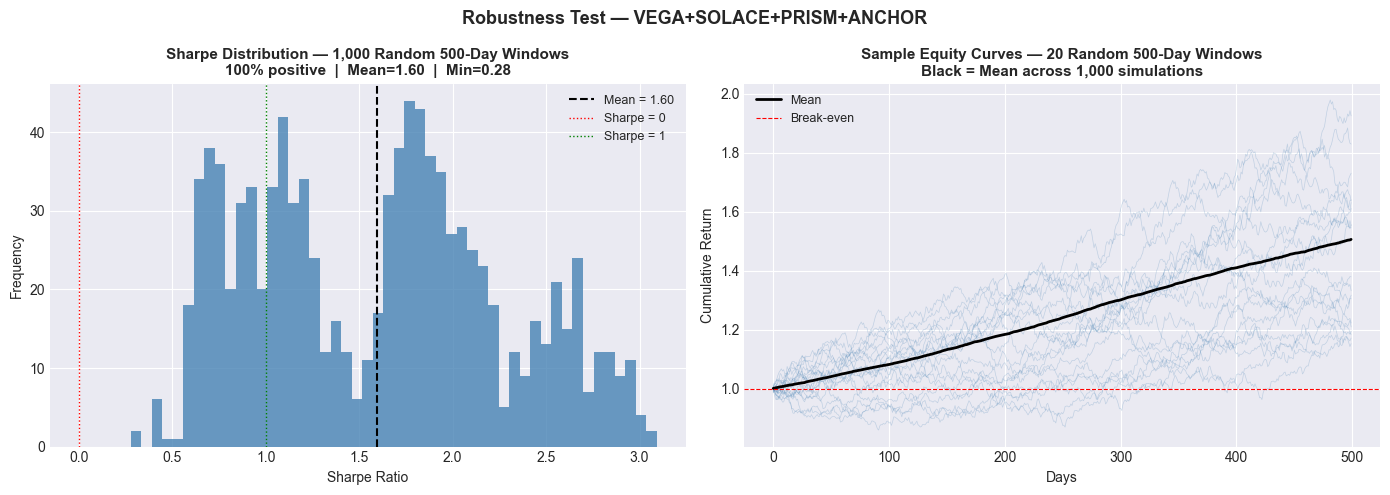

✅ robustness_final.png saved


In [14]:
# Final Charts for Report
# Requires: returns, prices already loaded
# Requires: sim_sharpes, candidates, N_SIMS, WINDOW_SIZE from robustness notebook

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')

ASSETS  = ['VEGA', 'SOLACE', 'PRISM', 'ANCHOR']
WEIGHTS = pd.Series({'VEGA': 0.4514, 'SOLACE': 0.3486, 'PRISM': 0.10, 'ANCHOR': 0.10})
TC      = 0.0005


# 1. In-Sample Equity Curve

port_ret    = (returns[ASSETS] * WEIGHTS).sum(axis=1).copy()
port_ret.iloc[0] -= TC * WEIGHTS.abs().sum()
cum_ret     = (1 + port_ret).cumprod()
rolling_max = cum_ret.cummax()
drawdown    = (cum_ret - rolling_max) / rolling_max
rolling_sharpe = port_ret.rolling(126).apply(
    lambda x: (x.mean()*252) / (x.std()*np.sqrt(252)) if x.std() > 0 else 0)

ann_ret = port_ret.mean() * 252
ann_vol = port_ret.std() * np.sqrt(252)
sharpe  = ann_ret / ann_vol
max_dd  = drawdown.min()

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

axes[0].plot(cum_ret.index, cum_ret.values, color='steelblue', linewidth=1.2)
axes[0].set_title(
    f'In-Sample Equity Curve — VEGA+SOLACE+PRISM+ANCHOR\n'
    f'Sharpe={sharpe:.2f}  Ann.Return={ann_ret:.2%}  Ann.Vol={ann_vol:.2%}',
    fontsize=12, fontweight='bold')
axes[0].set_ylabel('Cumulative Return')

axes[1].fill_between(drawdown.index, drawdown.values, 0, color='crimson', alpha=0.5)
axes[1].axhline(max_dd, color='black', linestyle='--', linewidth=1,
                label=f'Max Drawdown: {max_dd:.2%}')
axes[1].set_title('Drawdown', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Drawdown')
axes[1].legend(fontsize=9)

axes[2].plot(rolling_sharpe.index, rolling_sharpe.values, color='darkgreen', linewidth=1.0)
axes[2].axhline(0,      color='black', linewidth=0.8, linestyle='--')
axes[2].axhline(sharpe, color='green', linewidth=0.8, linestyle=':',
                label=f'Full period: {sharpe:.2f}')
axes[2].set_title('Rolling 6-Month Sharpe', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Sharpe Ratio')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('equity_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ equity_curve.png saved")


# 2. Robustness — Sharpe Distribution + Sample Equity Curves

CANDIDATE_NAME = 'OPT | VEGA+SOLACE+PRISM+ANCHOR'
arr    = np.array(sim_sharpes[CANDIDATE_NAME])
w      = candidates[CANDIDATE_NAME][1]
assets = candidates[CANDIDATE_NAME][0]

N_CURVES = 20
np.random.seed(None)

# Pre-compute mean curve
mean_cum = []
for _ in range(N_SIMS):
    start    = np.random.randint(0, len(returns) - WINDOW_SIZE)
    period   = returns[assets].iloc[start:start+WINDOW_SIZE]
    pr       = (period * w).sum(axis=1)
    mean_cum.append((1 + pr).cumprod().reset_index(drop=True).values)
mean_curve = np.mean(mean_cum, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sharpe distribution
axes[0].hist(arr, bins=50, color='steelblue', edgecolor='none', alpha=0.8)
axes[0].axvline(arr.mean(), color='black', linewidth=1.5, linestyle='--',
                label=f'Mean = {arr.mean():.2f}')
axes[0].axvline(0, color='red',   linewidth=1.0, linestyle=':', label='Sharpe = 0')
axes[0].axvline(1, color='green', linewidth=1.0, linestyle=':', label='Sharpe = 1')
axes[0].set_title(
    f'Sharpe Distribution — {len(arr):,} Random 500-Day Windows\n'
    f'100% positive  |  Mean={arr.mean():.2f}  |  Min={arr.min():.2f}',
    fontsize=11, fontweight='bold')
axes[0].set_xlabel('Sharpe Ratio')
axes[0].set_ylabel('Frequency')
axes[0].legend(fontsize=9)

# Sample equity curves
for _ in range(N_CURVES):
    start  = np.random.randint(0, len(returns) - WINDOW_SIZE)
    period = returns[assets].iloc[start:start+WINDOW_SIZE]
    pr     = (period * w).sum(axis=1)
    cum    = (1 + pr).cumprod().reset_index(drop=True)
    axes[1].plot(cum, color='steelblue', linewidth=0.5, alpha=0.25)

axes[1].plot(mean_curve, color='black', linewidth=2.0, label='Mean')
axes[1].axhline(1.0, color='red', linewidth=0.8, linestyle='--', label='Break-even')
axes[1].set_title(
    f'Sample Equity Curves — {N_CURVES} Random 500-Day Windows\n'
    f'Black = Mean across {N_SIMS:,} simulations',
    fontsize=11, fontweight='bold')
axes[1].set_xlabel('Days')
axes[1].set_ylabel('Cumulative Return')
axes[1].legend(fontsize=9)

plt.suptitle('Robustness Test — VEGA+SOLACE+PRISM+ANCHOR',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('robustness_final.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ robustness_final.png saved")